## Graphe mondial des villes avec chemin Dijkstra

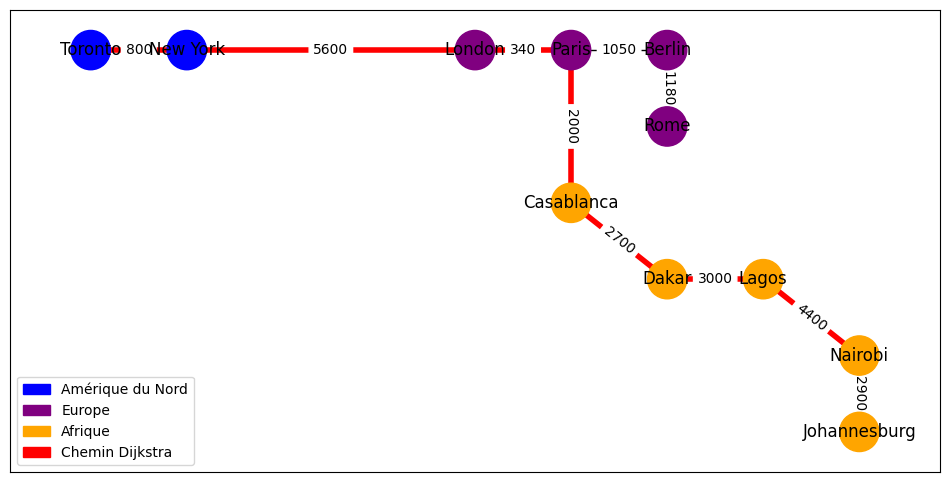

✅ Graphe sauvegardé dans images/graphe.png avec légende


In [16]:
# ==============================================
# Projet TP Dijkstra – Graphe mondial
# Étudiante : djelloul msili
# ID : 300155606
# Date : 23/03/2026
# ==============================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# --- Création du dossier images si inexistant ---
if not os.path.exists("images"):
    os.makedirs("images")

# --- Graphe ---
G = nx.Graph()

edges = [
    ('Toronto','New York',800),
    ('New York','London',5600),
    ('London','Paris',340),
    ('Paris','Berlin',1050),
    ('Berlin','Rome',1180),
    ('Paris','Casablanca',2000),
    ('Casablanca','Dakar',2700),
    ('Dakar','Lagos',3000),
    ('Lagos','Nairobi',4400),
    ('Nairobi','Johannesburg',2900),
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# Positions des villes
pos = {
    'Toronto':(-5,2),'New York':(-4,2),
    'London':(-1,2),'Paris':(0,2),'Berlin':(1,2),'Rome':(1,1),
    'Casablanca':(0,0),'Dakar':(1,-1),'Lagos':(2,-1),'Nairobi':(3,-2),'Johannesburg':(3,-3),
}

# Couleurs par continent
colors = {
    'Toronto':'blue','New York':'blue',       # Amérique du Nord
    'London':'purple','Paris':'purple','Berlin':'purple','Rome':'purple',  # Europe
    'Casablanca':'orange','Dakar':'orange','Lagos':'orange','Nairobi':'orange','Johannesburg':'orange'  # Afrique
}
node_colors = [colors[n] for n in G.nodes()]

# --- Dijkstra ---
path = nx.shortest_path(G, 'Toronto', 'Johannesburg', weight='weight')

plt.figure(figsize=(12,6))

# Noeuds colorés
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)

# Arêtes normales
nx.draw_networkx_edges(G, pos)

# Labels des villes
nx.draw_networkx_labels(G, pos)

# Chemin Dijkstra en rouge
nx.draw_networkx_edges(G, pos, edgelist=list(zip(path, path[1:])), width=4, edge_color='red')

# Labels des distances
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'weight'))

# --- Légende ---
patch_north = mpatches.Patch(color='blue', label='Amérique du Nord')
patch_europe = mpatches.Patch(color='purple', label='Europe')
patch_africa = mpatches.Patch(color='orange', label='Afrique')
patch_path = mpatches.Patch(color='red', label='Chemin Dijkstra')

plt.legend(handles=[patch_north, patch_europe, patch_africa, patch_path], loc='lower left')

# --- Sauvegarde ---
plt.savefig("images/graphe.png")
plt.show()

print("✅ Graphe sauvegardé dans images/graphe.png avec légende")